# Evaluating Unsupervised Models - Assignment

Companion to `Evaluating Unsupervised Models - Lab.ipynb`. The lab showed the diagnostics
working on data built to be easy. This notebook breaks that data on purpose and watches
which diagnostic notices first.

| Part | What it breaks | Diagnostic under test |
|---|---|---|
| 1 | clusters overlap (`cluster_std` up) | the silhouette peak, and how sharp it is |
| 2 | clusters have different widths | K-Means vs DBSCAN |
| 3 | there is no structure at all | the silhouette floor, stability |
| 4 | reading the elbow by eye | an automatic elbow finder |
| 5 | synthetic data | `choose_k` on a real dataset |

Every number below is computed live; nothing is copied from the lab.

---
## Part 0: Setup

Same imports, seed and house style as the lab, so the results are directly comparable.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, load_wine
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

SEED = 42
N_SAMPLES = 1200
TRUE_K = 4
K_RANGE = range(2, 11)

BLUE, TEAL, PALE, GREY = '#1C53A3', '#1CA387', '#6E93C8', '#9AA5B1'
plt.rcParams.update({
    'figure.figsize': (9, 4.5),
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('Setup complete.')

Setup complete.


### Helpers

Three functions reused in every part. `sweep_k` is Part 2 of the lab wrapped up so it can be
pointed at any dataset; `stability` is the bootstrap-agreement test from Part 3 of the lab,
unchanged.

In [2]:
def make_data(cluster_std, n_samples=N_SAMPLES, centers=TRUE_K, seed=SEED):
    '''make_blobs wrapper. cluster_std takes a scalar OR a list, one width per cluster.'''
    return make_blobs(n_samples=n_samples, centers=centers, n_features=2,
                      cluster_std=cluster_std, random_state=seed)


def sweep_k(X, k_range=K_RANGE, seed=SEED):
    '''Fit K-Means for every k in k_range and collect the three internal metrics.'''
    res = {'k': list(k_range), 'inertia': [], 'silhouette': [], 'davies_bouldin': []}
    for k in k_range:
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        res['inertia'].append(model.inertia_)
        res['silhouette'].append(silhouette_score(X, model.labels_))
        res['davies_bouldin'].append(davies_bouldin_score(X, model.labels_))
    return res


def report_sweep(res, label='', true_k=TRUE_K):
    '''Print the sweep table. Returns (best_k, peak, margin over the runner-up).'''
    sil = res['silhouette']
    order = np.argsort(sil)[::-1]
    best_k = res['k'][order[0]]
    margin = sil[order[0]] - sil[order[1]]

    if label:
        print(label)
    print(f'{"k":>3}  {"inertia":>10}  {"silhouette":>11}  {"Davies-Bouldin":>15}')
    for k, i, s, d in zip(res['k'], res['inertia'], sil, res['davies_bouldin']):
        mark = '  <-- silhouette peak' if k == best_k else ''
        print(f'{k:>3}  {i:>10.1f}  {s:>11.3f}  {d:>15.3f}{mark}')

    if true_k is None:
        verdict = 'no true k exists for this data'
    else:
        verdict = 'recovers the truth' if best_k == true_k else f'MISSES (true k = {true_k})'
    print(f'\nsilhouette peak: k = {best_k} at {sil[order[0]]:.3f}   '
          f'margin over runner-up (k={res["k"][order[1]]}): {margin:.3f}   {verdict}')
    return best_k, sil[order[0]], margin


def stability(X, k, n_trials=12, sample_frac=0.8, seed=SEED):
    '''
    Lab Part 3, unchanged: cluster many overlapping subsamples of ONE dataset, then
    measure how much the partitions agree on the points any two subsamples share.
    Returns mean pairwise ARI. 1.0 = perfectly reproducible, 0.0 = arbitrary.
    '''
    rng = np.random.default_rng(seed)
    n_sub = int(len(X) * sample_frac)

    runs = []
    for _ in range(n_trials):
        idx = rng.choice(len(X), size=n_sub, replace=False)
        labels = KMeans(n_clusters=k, n_init=10,
                        random_state=int(rng.integers(1e6))).fit_predict(X[idx])
        assignment = np.full(len(X), -1)   # -1 = point not in this subsample
        assignment[idx] = labels
        runs.append(assignment)

    scores = []
    for a in range(len(runs)):
        for b in range(a + 1, len(runs)):
            shared = (runs[a] >= 0) & (runs[b] >= 0)
            scores.append(adjusted_rand_score(runs[a][shared], runs[b][shared]))
    return float(np.mean(scores))


print('Helpers defined.')

Helpers defined.


---
## Part 1: Make the problem harder

> Regenerate the data with `cluster_std=2.5` instead of `1.15`, then rerun Part 2.
>
> - Does silhouette still peak at 4?
> - Does the peak get flatter? What does a flat peak mean about your confidence in k?
> - At what `cluster_std` does the method stop recovering the truth?

"Stop recovering the truth" needs a definition, so we track two things at every setting:

- **which k the peak lands on** - the hard failure
- **the margin**, peak silhouette minus the runner-up's - how much the peak is actually
  worth as evidence

The margin is the number to watch. A peak of 0.76 that beats its neighbour by 0.15 is a
finding; a peak that beats its neighbour by 0.003 is a coin toss wearing a decimal point.

In [3]:
# The lab's easy data, as the baseline we degrade away from.
X_easy, y_easy = make_data(1.15)
res_easy = sweep_k(X_easy)
best_easy, peak_easy, margin_easy = report_sweep(res_easy, 'cluster_std = 1.15  (the lab baseline)')

cluster_std = 1.15  (the lab baseline)
  k     inertia   silhouette   Davies-Bouldin
  2     39144.6        0.579            0.547
  3      9626.9        0.735            0.380
  4      3068.6        0.763            0.330  <-- silhouette peak
  5      2776.7        0.634            0.683
  6      2490.9        0.517            0.912
  7      2239.7        0.419            1.066
  8      1978.3        0.328            1.177
  9      1800.3        0.338            1.070
 10      1652.8        0.335            1.014

silhouette peak: k = 4 at 0.763   margin over runner-up (k=3): 0.027   recovers the truth


In [4]:
# Same generator, same seed, same 1200 points - only the blob width changes.
X_hard, y_hard = make_data(2.5)
res_hard = sweep_k(X_hard)
best_hard, peak_hard, margin_hard = report_sweep(res_hard, 'cluster_std = 2.5  (the assignment)')

cluster_std = 2.5  (the assignment)
  k     inertia   silhouette   Davies-Bouldin
  2     51227.4        0.483            0.730
  3     20485.7        0.579            0.569  <-- silhouette peak
  4     13335.4        0.533            0.656
  5     11923.9        0.475            0.807
  6     10556.9        0.402            0.979
  7      9253.7        0.332            1.095
  8      8234.7        0.332            1.050
  9      7486.8        0.329            1.002
 10      6747.2        0.334            0.970

silhouette peak: k = 3 at 0.579   margin over runner-up (k=4): 0.046   MISSES (true k = 4)


### Why that particular k, and not some other wrong one

Before scanning, it is worth knowing the geometry we are dissolving. `make_blobs` scatters
the four centres at random, and they are not equally spaced - so as the blobs widen, the
*closest pair* is the one that merges first. That predicts which wrong answer we will get.

In [5]:
_, _, centres = make_blobs(n_samples=N_SAMPLES, centers=TRUE_K, n_features=2,
                           cluster_std=1.15, random_state=SEED, return_centers=True)

print('centre coordinates:')
for i, c in enumerate(centres):
    print(f'  cluster {i}: ({c[0]:>6.2f}, {c[1]:>6.2f})')

print('\npairwise centre distances:')
gaps = []
for i in range(TRUE_K):
    for j in range(i + 1, TRUE_K):
        d = float(np.linalg.norm(centres[i] - centres[j]))
        gaps.append((d, i, j))
        print(f'  {i} <-> {j}:  {d:>6.2f}')

gaps.sort()
d_min, i_min, j_min = gaps[0]
print(f'\nclosest pair: clusters {i_min} and {j_min}, {d_min:.2f} apart')
print(f'next closest is {gaps[1][0]:.2f} - so one pair is much closer than the rest')
print(f'\nAt cluster_std = s, that gap is {d_min:.2f}/s standard deviations wide:')
for s in [1.15, 1.5, 2.5, 4.0]:
    print(f'  s = {s:>4}: {d_min / s:>5.2f} sd  -> merging {i_min} and {j_min} would leave k = 3')

centre coordinates:
  cluster 0: ( -2.51,   9.01)
  cluster 1: (  4.64,   1.97)
  cluster 2: ( -6.88,  -6.88)
  cluster 3: ( -8.84,   7.32)

pairwise centre distances:
  0 <-> 1:   10.03
  0 <-> 2:   16.48
  0 <-> 3:    6.55
  1 <-> 2:   14.53
  1 <-> 3:   14.50
  2 <-> 3:   14.34

closest pair: clusters 0 and 3, 6.55 apart
next closest is 10.03 - so one pair is much closer than the rest

At cluster_std = s, that gap is 6.55/s standard deviations wide:
  s = 1.15:  5.70 sd  -> merging 0 and 3 would leave k = 3
  s =  1.5:  4.37 sd  -> merging 0 and 3 would leave k = 3
  s =  2.5:  2.62 sd  -> merging 0 and 3 would leave k = 3
  s =  4.0:  1.64 sd  -> merging 0 and 3 would leave k = 3


In [6]:
# Sweep the honesty dial and record what silhouette decides at each setting.
# Fine steps near the bottom, because that is where the answer turns out to be.
std_values = [1.15, 1.2, 1.3, 1.4, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]
rows = []

for std in std_values:
    X_s, y_s = make_data(std)
    res_s = sweep_k(X_s)
    sil = res_s['silhouette']
    order = np.argsort(sil)[::-1]

    # ARI of the k=4 fit against the truth: how much real structure survives at all.
    labels4 = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit_predict(X_s)
    rows.append({
        'std': std,
        'k_pick': res_s['k'][order[0]],
        'peak': sil[order[0]],
        'margin': sil[order[0]] - sil[order[1]],
        'sil_at_4': sil[res_s['k'].index(TRUE_K)],
        'ari_at_4': adjusted_rand_score(y_s, labels4),
    })

print(f'{"cluster_std":>11}  {"k chosen":>8}  {"peak sil":>9}  {"margin":>7}  '
      f'{"sil @ k=4":>9}  {"ARI @ k=4":>9}')
for r in rows:
    flag = '' if r['k_pick'] == TRUE_K else '   <-- wrong k'
    print(f'{r["std"]:>11.2f}  {r["k_pick"]:>8}  {r["peak"]:>9.3f}  {r["margin"]:>7.3f}  '
          f'{r["sil_at_4"]:>9.3f}  {r["ari_at_4"]:>9.3f}{flag}')

first_fail = next((r['std'] for r in rows if r['k_pick'] != TRUE_K), None)
last_ok = max((r['std'] for r in rows if r['k_pick'] == TRUE_K), default=None)
print(f'\nlast cluster_std that still picks k=4: {last_ok}')
print(f'first cluster_std that does not:      {first_fail}')

cluster_std  k chosen   peak sil   margin  sil @ k=4  ARI @ k=4
       1.15         4      0.763    0.027      0.763      0.998
       1.20         4      0.752    0.023      0.752      0.998
       1.30         4      0.732    0.014      0.732      0.991
       1.40         4      0.712    0.006      0.712      0.991
       1.50         3      0.695    0.003      0.692      0.980   <-- wrong k
       2.00         3      0.636    0.031      0.604      0.927   <-- wrong k
       2.50         3      0.579    0.046      0.533      0.855   <-- wrong k
       3.00         3      0.529    0.054      0.476      0.784   <-- wrong k
       3.50         3      0.489    0.058      0.431      0.694   <-- wrong k
       4.00         3      0.454    0.054      0.400      0.588   <-- wrong k
       5.00         3      0.406    0.045      0.361      0.436   <-- wrong k
       6.00         3      0.375    0.032      0.343      0.336   <-- wrong k

last cluster_std that still picks k=4: 1.4
first cluste

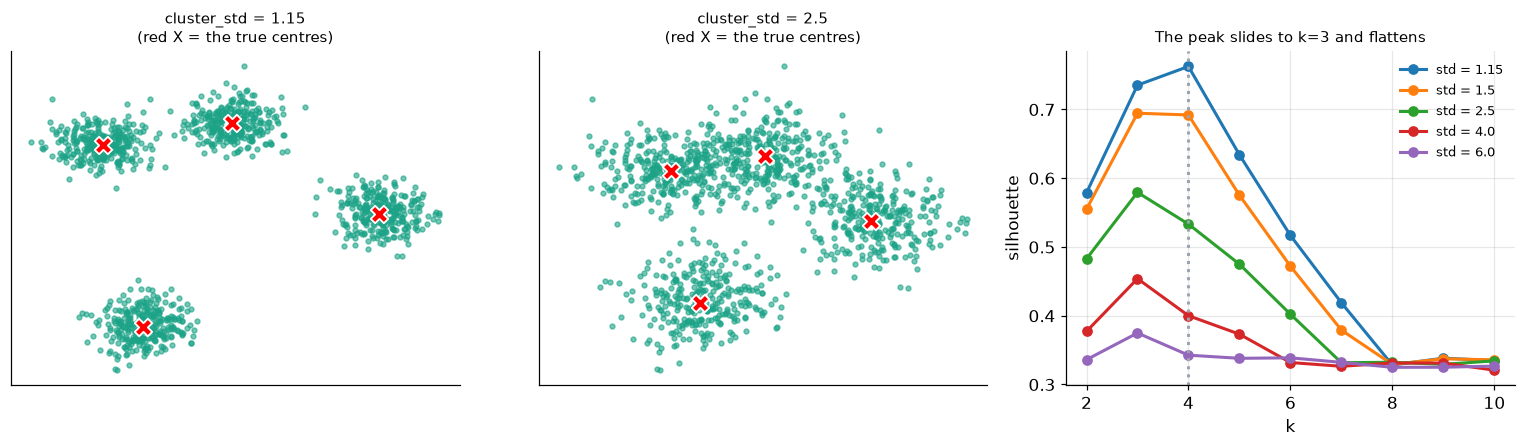

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, (X, std) in zip(axes[:2], [(X_easy, 1.15), (X_hard, 2.5)]):
    ax.scatter(X[:, 0], X[:, 1], s=10, c=TEAL, alpha=0.6)
    ax.scatter(centres[:, 0], centres[:, 1], c='red', marker='X', s=130,
               edgecolor='white', linewidth=1.2, zorder=3)
    ax.set_title(f'cluster_std = {std}\n(red X = the true centres)', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

for std in [1.15, 1.5, 2.5, 4.0, 6.0]:
    res_s = sweep_k(make_data(std)[0])
    axes[2].plot(res_s['k'], res_s['silhouette'], 'o-', linewidth=2, label=f'std = {std}')
axes[2].axvline(TRUE_K, color=GREY, linestyle=':', linewidth=2)
axes[2].set_xlabel('k'); axes[2].set_ylabel('silhouette')
axes[2].set_title('The peak slides to k=3 and flattens', fontsize=10)
axes[2].legend(frameon=False, fontsize=8.5)

plt.tight_layout(); plt.show()

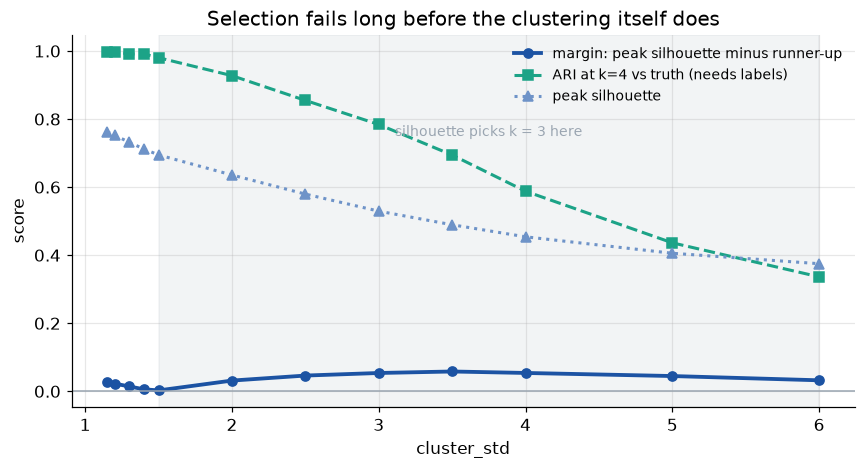

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.4))
stds = [r['std'] for r in rows]

ax.plot(stds, [r['margin'] for r in rows], 'o-', color=BLUE, linewidth=2.5,
        label='margin: peak silhouette minus runner-up')
ax.plot(stds, [r['ari_at_4'] for r in rows], 's--', color=TEAL, linewidth=2,
        label='ARI at k=4 vs truth (needs labels)')
ax.plot(stds, [r['peak'] for r in rows], '^:', color=PALE, linewidth=2,
        label='peak silhouette')

wrong = [r['std'] for r in rows if r['k_pick'] != TRUE_K]
if wrong:
    ax.axvspan(min(wrong), max(stds), color=GREY, alpha=0.12)
    ax.text((min(wrong) + max(stds)) / 2, 0.75,
            'silhouette picks k = 3 here', color=GREY, fontsize=9, ha='center')

ax.axhline(0, color=GREY, linewidth=1)
ax.set_xlabel('cluster_std'); ax.set_ylabel('score')
ax.set_title('Selection fails long before the clustering itself does')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### Part 1 answers

**Does silhouette still peak at 4?** No. At `cluster_std=2.5` the peak moves to **k = 3**
(0.579), with the true k = 4 in second place at 0.533.

Note carefully what did *not* fail: the k=4 fit still recovers the truth almost perfectly
at that setting (**ARI 0.855**). The clustering is fine; what broke is *choosing* k.

**Does the peak get flatter?** Yes - and the flattening arrives earlier than the error
does, which makes it the more useful warning:

| cluster_std | k chosen | peak silhouette | margin over runner-up | ARI at k=4 |
|---|---|---|---|---|
| 1.15 | 4 | 0.763 | 0.027 | 0.998 |
| 1.30 | 4 | 0.732 | 0.014 | 0.991 |
| 1.40 | 4 | 0.712 | **0.006** | 0.991 |
| 1.50 | **3** | 0.695 | 0.003 | 0.980 |
| 2.50 | **3** | 0.579 | 0.046 | 0.855 |

At `std = 1.4` the margin has collapsed to 0.006 while the answer is *still correct*. That
is the honest signal: the peak is in the right place but is no longer distinguishable from
its neighbour. A flat peak means **the data does not contain enough evidence to prefer one
k over the next**, and the right response is to report a range ("k is 3 or 4, and the data
cannot separate them") rather than a number.

There is a trap in that table worth naming. Past `std = 1.5` the margin **grows again**
(0.031, 0.046, 0.054, 0.058). Confidence comes back - pointed firmly at the wrong answer.
The margin measures how cleanly one partition beats another, not whether it is the true
one. **A large margin is not evidence of correctness.** It is only informative in the
direction of doubt: a small margin reliably means "do not commit", a large one means
nothing on its own.

**At what `cluster_std` does the method stop recovering the truth?** Between **1.4 and
1.5** - far earlier than the lab's framing suggests. But "stop recovering the truth" splits
into two thresholds that are a long way apart:

- **selection** breaks at `std ~ 1.5`, when the peak moves to k=3
- **the clustering itself** survives much longer: ARI at k=4 is 0.980 at std=1.5, 0.855 at
  2.5, 0.588 at 4.0, and only falls below 0.5 around std=5

So there is a wide band - roughly std 1.5 to 4 - where K-Means fitted at the correct k
would recover the structure well, but no internal metric will tell you that 4 was the
correct k to ask for.

**And why k=3 in particular?** The geometry cell answers this. The four centres are not
equally spaced: clusters 0 and 3 sit **6.55** apart while every other pair is at least
10.03. That gap is 5.7 standard deviations wide at std=1.15 but only 4.4 at std=1.5 and
2.6 at std=2.5. The closest pair merges first, leaving three visible groups. The failure
mode was predictable from the centres alone, before running any metric - which is the
general lesson: **check how separated your clusters are relative to their width, because
that ratio, not the number of clusters, decides whether any of this works.**

---
## Part 2: Clusters of unequal size

> `make_blobs` accepts a list for `cluster_std`, e.g. `[0.5, 0.5, 3.0, 0.5]`, giving one
> wide cluster and three tight ones.
>
> - What does K-Means do to the wide cluster, and why?
> - Does DBSCAN handle it better? Why does the answer differ between the two?

### 2a: The setting the brief suggests

In [9]:
X_uneq, y_uneq = make_data([0.5, 0.5, 3.0, 0.5])
print('true cluster sizes:', np.bincount(y_uneq))

km4 = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit(X_uneq)
pred_km = km4.labels_
ari_km_uneq = adjusted_rand_score(y_uneq, pred_km)
print('K-Means cluster sizes:', np.bincount(pred_km))
print(f'ARI vs truth: {ari_km_uneq:.3f}')

print('\nrows = true cluster (2 is the wide one), cols = K-Means cluster')
table = np.zeros((TRUE_K, TRUE_K), dtype=int)
for t, p in zip(y_uneq, pred_km):
    table[t, p] += 1
print(f'{"":>16}' + ''.join(f'{c:>7}' for c in range(TRUE_K)))
for t in range(TRUE_K):
    name = f'true {t} ({"WIDE" if t == 2 else "tight"})'
    print(f'{name:>16}' + ''.join(f'{v:>7}' for v in table[t]))

true cluster sizes: [300 300 300 300]


K-Means cluster sizes: [305 294 301 300]
ARI vs truth: 0.987

rows = true cluster (2 is the wide one), cols = K-Means cluster
                      0      1      2      3
  true 0 (tight)      0      0      0    300
  true 1 (tight)      0      0    300      0
   true 2 (WIDE)      5    294      1      0
  true 3 (tight)    300      0      0      0


That barely broke. The reason is in the geometry we printed in Part 1: with `random_state=42`
the closest two centres are still 6.55 apart, so a cluster of width 3.0 does not actually
reach its neighbours. **Unequal widths on their own are not the problem - unequal widths
*plus* overlap are.**

So build the setting the brief is really pointing at: put the wide cluster in the middle,
make it genuinely wide, and give it more of the points. Now its skirts land on top of the
tight clusters, and K-Means has to decide who owns them.

### 2b: The setting where it actually bites

In [10]:
# Explicit centres, so separation is a controlled quantity rather than a lottery.
centres_mix = np.array([[0.0, 0.0],     # the WIDE one, in the middle
                        [6.0, 0.0],     # tight
                        [-6.0, 0.0],    # tight
                        [0.0, 6.0]])    # tight
widths_mix = [3.5, 0.4, 0.4, 0.4]
sizes_mix = [600, 200, 200, 200]        # the wide cluster also dominates the point count

X_mix, y_mix = make_blobs(n_samples=sizes_mix, centers=centres_mix, n_features=2,
                          cluster_std=widths_mix, random_state=SEED)
print('true sizes:', np.bincount(y_mix), '   widths:', widths_mix)

km_mix = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit(X_mix)
pred_mix = km_mix.labels_
ari_km_mix = adjusted_rand_score(y_mix, pred_mix)
print('K-Means sizes:', np.bincount(pred_mix))
print(f'ARI vs truth: {ari_km_mix:.3f}    (2a scored {ari_km_uneq:.3f})')

print('\nrows = true cluster (0 is the WIDE one), cols = K-Means cluster')
table_mix = np.zeros((TRUE_K, TRUE_K), dtype=int)
for t, p in zip(y_mix, pred_mix):
    table_mix[t, p] += 1
print(f'{"":>16}' + ''.join(f'{c:>7}' for c in range(TRUE_K)))
for t in range(TRUE_K):
    name = f'true {t} ({"WIDE" if t == 0 else "tight"})'
    print(f'{name:>16}' + ''.join(f'{v:>7}' for v in table_mix[t]))

print('\nfragmentation - K-Means clusters holding a substantial share of each true cluster:')
for t in range(TRUE_K):
    share = table_mix[t] / table_mix[t].sum()
    n_parts = int((share > 0.10).sum())
    print(f'  true cluster {t} ({"WIDE " if t == 0 else "tight"}): split across {n_parts} '
          f'K-Means cluster(s)   shares: {np.round(share, 2)}')

print('\nand how much of each K-Means cluster is actually foreign material:')
for p in range(TRUE_K):
    col = table_mix[:, p]
    purity = col.max() / col.sum()
    print(f'  K-Means cluster {p}: {col.sum():>4} points, purity {purity:.2f} '
          f'(dominant true cluster: {int(col.argmax())})')

true sizes: [600 200 200 200]    widths: [3.5, 0.4, 0.4, 0.4]


K-Means sizes: [314 234 316 336]
ARI vs truth: 0.323    (2a scored 0.987)

rows = true cluster (0 is the WIDE one), cols = K-Means cluster
                      0      1      2      3
   true 0 (WIDE)    114    234    116    136
  true 1 (tight)      0      0    200      0
  true 2 (tight)    200      0      0      0
  true 3 (tight)      0      0      0    200

fragmentation - K-Means clusters holding a substantial share of each true cluster:
  true cluster 0 (WIDE ): split across 4 K-Means cluster(s)   shares: [0.19 0.39 0.19 0.23]
  true cluster 1 (tight): split across 1 K-Means cluster(s)   shares: [0. 0. 1. 0.]
  true cluster 2 (tight): split across 1 K-Means cluster(s)   shares: [1. 0. 0. 0.]
  true cluster 3 (tight): split across 1 K-Means cluster(s)   shares: [0. 0. 0. 1.]

and how much of each K-Means cluster is actually foreign material:
  K-Means cluster 0:  314 points, purity 0.64 (dominant true cluster: 2)
  K-Means cluster 1:  234 points, purity 1.00 (dominant true cluste

In [11]:
# The mechanism, stated as a number: K-Means wants clusters of equal RADIUS.
print('radius of each fitted K-Means cluster (mean distance from its own centre):')
for p in range(TRUE_K):
    pts = X_mix[pred_mix == p]
    r = np.linalg.norm(pts - km_mix.cluster_centers_[p], axis=1).mean()
    print(f'  K-Means cluster {p}: {r:.2f}')

print('\nradius of each TRUE cluster:')
for t in range(TRUE_K):
    pts = X_mix[y_mix == t]
    r = np.linalg.norm(pts - pts.mean(axis=0), axis=1).mean()
    print(f'  true cluster {t} ({"WIDE " if t == 0 else "tight"}): {r:.2f}')

print('\nK-Means minimises total squared distance, so it prefers cells of similar size.')
print('The true radii differ by ~10x, which is a shape it has no way to represent.')

radius of each fitted K-Means cluster (mean distance from its own centre):
  K-Means cluster 0: 1.57
  K-Means cluster 1: 2.69
  K-Means cluster 2: 1.48
  K-Means cluster 3: 1.57

radius of each TRUE cluster:
  true cluster 0 (WIDE ): 4.34
  true cluster 1 (tight): 0.51
  true cluster 2 (tight): 0.48
  true cluster 3 (tight): 0.48

K-Means minimises total squared distance, so it prefers cells of similar size.
The true radii differ by ~10x, which is a shape it has no way to represent.


In [12]:
# DBSCAN on the same hard data. Its dial is eps, so scan it.
print('DBSCAN on the 2b data (min_samples=8):')
print(f'{"eps":>6}  {"clusters":>8}  {"noise %":>8}  {"ARI":>7}')
db_rows = []
for eps in [0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0]:
    labels = DBSCAN(eps=eps, min_samples=8).fit_predict(X_mix)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = 100 * np.mean(labels == -1)
    ari = adjusted_rand_score(y_mix, labels)   # noise (-1) counts as its own group
    db_rows.append((eps, n_clusters, noise_pct, ari, labels))
    print(f'{eps:>6.2f}  {n_clusters:>8}  {noise_pct:>8.1f}  {ari:>7.3f}')

best_eps, best_nc, best_noise, best_ari, best_labels = max(db_rows, key=lambda r: r[3])
print(f'\nbest DBSCAN:      eps = {best_eps}, {best_nc} clusters, '
      f'{best_noise:.1f}% noise, ARI = {best_ari:.3f}')
print(f'K-Means k=4:      ARI = {ari_km_mix:.3f}')
print('\nNote what "best" required: picking eps by looking at the ARI, which needs the'
      '\nlabels. With no labels you would be choosing from the clusters/noise columns alone.')

DBSCAN on the 2b data (min_samples=8):
   eps  clusters   noise %      ARI


  0.20         3      55.9    0.766
  0.30         3      49.5    0.907


  0.40         5      46.5    0.883


  0.50        15      34.7    0.649
  0.70         6      15.0    0.426


  1.00         1       7.3   -0.056
  1.50         1       2.5   -0.023


  2.00         1       0.9   -0.009
  3.00         1       0.2   -0.002


  4.00         1       0.1   -0.001

best DBSCAN:      eps = 0.3, 3 clusters, 49.5% noise, ARI = 0.907
K-Means k=4:      ARI = 0.323

Note what "best" required: picking eps by looking at the ARI, which needs the
labels. With no labels you would be choosing from the clusters/noise columns alone.


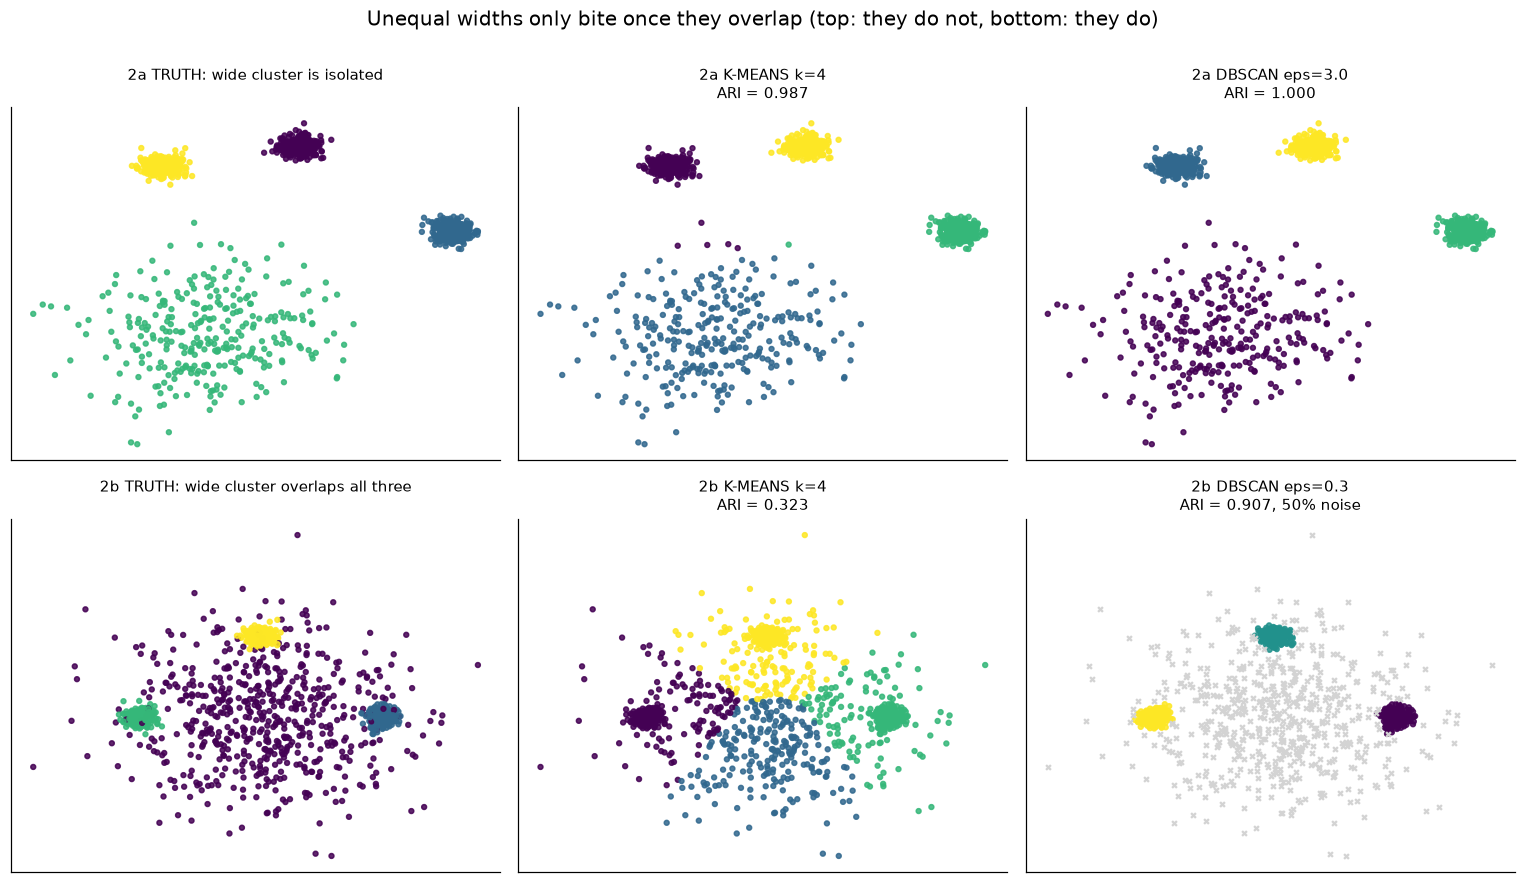

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Top row: the easy setting from 2a.
db_uneq = [(eps, DBSCAN(eps=eps, min_samples=8).fit_predict(X_uneq))
           for eps in [0.3, 0.5, 1.0, 2.0, 3.0]]
best_eps_a, best_lab_a = max(db_uneq, key=lambda r: adjusted_rand_score(y_uneq, r[1]))

for ax, (title, labels, extra) in zip(axes[0], [
        ('2a TRUTH: wide cluster is isolated', y_uneq, ''),
        ('2a K-MEANS k=4', pred_km, f'ARI = {ari_km_uneq:.3f}'),
        (f'2a DBSCAN eps={best_eps_a}', best_lab_a,
         f'ARI = {adjusted_rand_score(y_uneq, best_lab_a):.3f}')]):
    noise = labels == -1
    ax.scatter(X_uneq[~noise, 0], X_uneq[~noise, 1], c=labels[~noise], cmap='viridis',
               s=10, alpha=0.85)
    ax.scatter(X_uneq[noise, 0], X_uneq[noise, 1], c='lightgrey', s=10, marker='x')
    ax.set_title(f'{title}\n{extra}', fontsize=10)

# Bottom row: the hard setting from 2b.
for ax, (title, labels, extra) in zip(axes[1], [
        ('2b TRUTH: wide cluster overlaps all three', y_mix, ''),
        ('2b K-MEANS k=4', pred_mix, f'ARI = {ari_km_mix:.3f}'),
        (f'2b DBSCAN eps={best_eps}', best_labels,
         f'ARI = {best_ari:.3f}, {best_noise:.0f}% noise')]):
    noise = labels == -1
    ax.scatter(X_mix[~noise, 0], X_mix[~noise, 1], c=labels[~noise], cmap='viridis',
               s=10, alpha=0.85)
    ax.scatter(X_mix[noise, 0], X_mix[noise, 1], c='lightgrey', s=10, marker='x')
    ax.set_title(f'{title}\n{extra}', fontsize=10)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle('Unequal widths only bite once they overlap (top: they do not, bottom: they do)',
             y=1.0)
plt.tight_layout(); plt.show()

### Part 2 answers

**What does K-Means do to the wide cluster, and why?**

First, an honest negative result: **the setting in the brief does not break it.**
`cluster_std=[0.5, 0.5, 3.0, 0.5]` scored **ARI 0.987**, with the wide cluster kept intact
(294 of its 300 points in a single K-Means cluster). The reason is the geometry from Part 1
- the closest two centres are 6.55 apart, so a cluster of width 3.0 still does not reach
its neighbours. **Unequal widths on their own are not the problem; unequal widths *plus*
overlap are.** Worth knowing, because a lab exercise that "fails to fail" is easy to write
up as a success.

Setting 2b builds the overlap deliberately - the wide cluster (std 3.5) in the middle
holding 600 of the 1200 points, three tight ones (std 0.4) at distance 6 - and now K-Means
fails hard: **ARI 0.323**, with the wide cluster **quartered across all four** K-Means
clusters (shares 0.19 / 0.39 / 0.19 / 0.23).

The mechanism is visible in the radii:

| | fitted K-Means radii | true radii |
|---|---|---|
| | 1.48, 1.57, 1.57, 2.69 | 0.48, 0.48, 0.51, **4.34** |

K-Means minimises total *squared* distance to centroids, and its decision boundaries are
the Voronoi tessellation of those centroids - so every cell is convex and they come out at
comparable radii. It squeezed a 10x spread of true radii into a 1.8x spread of fitted ones,
because a cluster 4.34 wide sitting beside clusters 0.5 wide is a shape it has **no
parameters to represent**.

So it does the only thing available: the wide cluster is expensive in squared distance, so
its outskirts get handed to whichever tight centroid is nearest. Note the direction of the
damage - the tight clusters were not destroyed, they were **inflated with stolen material**.
Their fitted cells end up only 60-64% pure while holding all 200 of their own points. If
you had profiled those three segments you would have been describing three clean groups
each diluted with about a third foreign material, with nothing in the output to suggest it.

**Does DBSCAN handle it better? Why does the answer differ?**

Better - **ARI 0.907 (eps=0.3) against 0.323** - but read what it actually reported:
**3 clusters and 49.5% of the data labelled noise.** It recovered the three tight clusters
and threw most of the wide one away. That is arguably the more honest description of this
data (a diffuse background is not a cluster), but it is not "found the four groups", and
you would only know it was a background rather than an error by looking.

The answers differ because the two algorithms mean different things by "cluster":

- **K-Means**: a cluster is a *region around a centroid*. Every point must join one, and
  density is not part of the model at all - so varying density is invisible to it and it
  can only respond by moving boundaries.
- **DBSCAN**: a cluster is a *connected region of sufficient density*, and points in sparse
  regions are allowed to belong to nothing. Unequal width means unequal density, and only
  DBSCAN has vocabulary for that.

But DBSCAN's advantage here is narrow, and its failure is worse. At `eps >= 1.0` it
collapses to **a single cluster with ARI around zero** (-0.056, -0.023, -0.009, -0.002):
the wide cluster is dense enough to act as a bridge, so once eps spans its interior,
single-linkage chaining welds all three tight clusters into one blob. K-Means degrades
gracefully; DBSCAN falls off a cliff. And one *global* eps cannot serve two densities at
once - which is precisely the limitation HDBSCAN exists to remove.

One caveat on the comparison, which the notebook prints rather than hides: I chose eps=0.3
**by maximising ARI, which needs the labels.** Judging from what you would actually have -
the clusters and noise% columns - eps=0.3 (3 clusters, 50% noise) does not obviously look
better than eps=0.7 (6 clusters, 15% noise), which scores 0.426. DBSCAN's win here is
partly a win of hindsight.

---
## Part 3: When there is no structure at all

> The most important negative result. Replace the data with pure noise.
>
> - K-Means will still return clusters. What is the silhouette peak?
> - Compare it to the ~0.76 we saw on real structure. Where would you set your own
>   threshold for "this is probably not real"?
> - What does the stability test say?

This is the control experiment. Any diagnostic that cannot tell this dataset apart from the
lab's four blobs is not a diagnostic.

In [14]:
X_noise = np.random.default_rng(0).normal(size=(1200, 2))

res_noise = sweep_k(X_noise)
best_noise_k, peak_noise, margin_noise = report_sweep(
    res_noise, 'pure 2-D Gaussian noise - there is no true k', true_k=None)

print(f'\nreal structure (std=1.15) peaked at {peak_easy:.3f}  with margin {margin_easy:.3f}')
print(f'pure noise               peaks at {peak_noise:.3f}  with margin {margin_noise:.3f}')
print(f'ratio of peaks: {peak_easy / peak_noise:.2f}x')

pure 2-D Gaussian noise - there is no true k
  k     inertia   silhouette   Davies-Bouldin
  2      1600.2        0.317            1.230
  3      1089.2        0.335            0.941  <-- silhouette peak
  4       853.1        0.316            0.941
  5       719.6        0.313            0.919
  6       588.8        0.329            0.838
  7       519.0        0.325            0.870
  8       463.6        0.318            0.858
  9       418.3        0.318            0.869
 10       379.9        0.320            0.840

silhouette peak: k = 3 at 0.335   margin over runner-up (k=6): 0.006   no true k exists for this data

real structure (std=1.15) peaked at 0.763  with margin 0.027
pure noise               peaks at 0.335  with margin 0.006
ratio of peaks: 2.28x


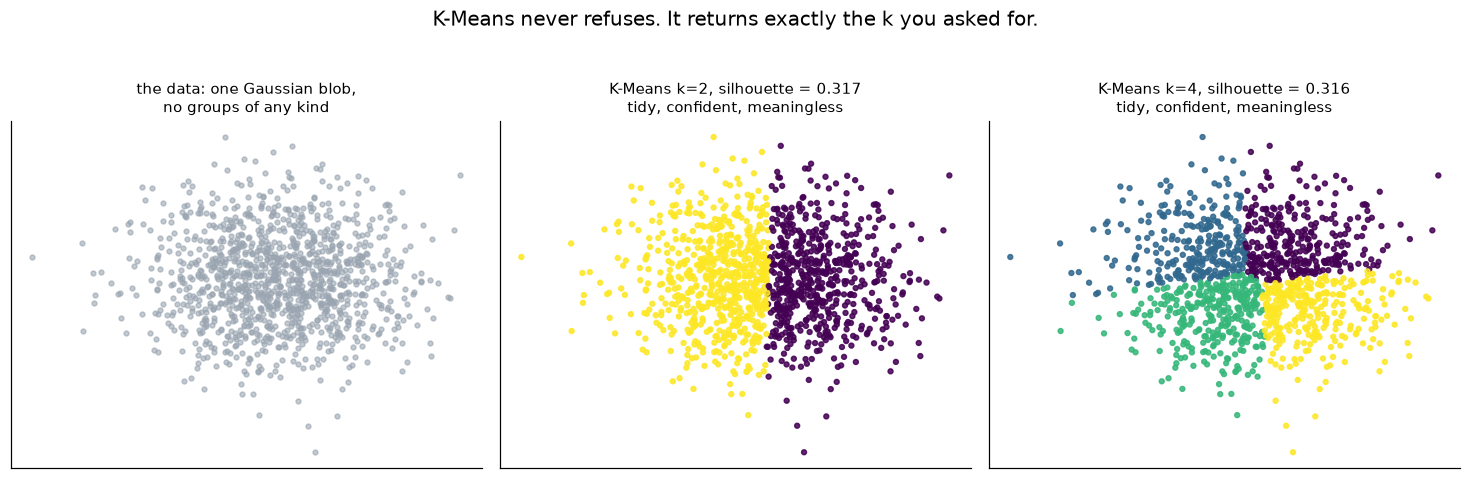

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].scatter(X_noise[:, 0], X_noise[:, 1], s=10, c=GREY, alpha=0.6)
axes[0].set_title('the data: one Gaussian blob,\nno groups of any kind', fontsize=10)

for ax, k in zip(axes[1:], [2, 4]):
    labels = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_noise)
    ax.scatter(X_noise[:, 0], X_noise[:, 1], c=labels, cmap='viridis', s=10, alpha=0.85)
    ax.set_title(f'K-Means k={k}, silhouette = '
                 f'{silhouette_score(X_noise, labels):.3f}\ntidy, confident, meaningless',
                 fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle('K-Means never refuses. It returns exactly the k you asked for.', y=1.03)
plt.tight_layout(); plt.show()

### 3.1 The noise floor is not a constant

Before adopting any threshold, one caveat worth measuring: the silhouette a *structureless*
dataset can reach depends on its shape - how many dimensions, how many points. A rule of
thumb learned in 2-D does not transfer. So calibrate it rather than memorise it.

In [16]:
print('silhouette achievable on pure noise, by dimensionality:')
print(f'{"dims":>5}  {"n":>6}  {"peak silhouette":>16}  {"at k":>5}  {"margin":>7}')
floors = {}
for n_dims in [2, 5, 10, 20, 50]:
    Xn = np.random.default_rng(0).normal(size=(1200, n_dims))
    sil = [silhouette_score(Xn, KMeans(n_clusters=k, n_init=10, random_state=SEED)
                            .fit_predict(Xn)) for k in K_RANGE]
    order = np.argsort(sil)[::-1]
    floors[n_dims] = sil[order[0]]
    print(f'{n_dims:>5}  {1200:>6}  {sil[order[0]]:>16.3f}  {list(K_RANGE)[order[0]]:>5}  '
          f'{sil[order[0]] - sil[order[1]]:>7.3f}')

print('\nAnd by sample size, in 2-D:')
print(f'{"dims":>5}  {"n":>6}  {"peak silhouette":>16}  {"at k":>5}  {"margin":>7}')
for n in [100, 300, 1200, 3000]:
    Xn = np.random.default_rng(0).normal(size=(n, 2))
    sil = [silhouette_score(Xn, KMeans(n_clusters=k, n_init=10, random_state=SEED)
                            .fit_predict(Xn)) for k in K_RANGE]
    order = np.argsort(sil)[::-1]
    print(f'{2:>5}  {n:>6}  {sil[order[0]]:>16.3f}  {list(K_RANGE)[order[0]]:>5}  '
          f'{sil[order[0]] - sil[order[1]]:>7.3f}')

print('\nThe honest procedure: shuffle or resample YOUR data to destroy its structure,')
print('rerun the sweep, and use the score you get as the threshold for that dataset.')

silhouette achievable on pure noise, by dimensionality:
 dims       n   peak silhouette   at k   margin


    2    1200             0.335      3    0.006


    5    1200             0.145      9    0.004


   10    1200             0.073     10    0.001


   20    1200             0.039      2    0.001


   50    1200             0.018      2    0.002

And by sample size, in 2-D:
 dims       n   peak silhouette   at k   margin


    2     100             0.380      9    0.025


    2     300             0.351      3    0.004


    2    1200             0.335      3    0.006


    2    3000             0.339      3    0.015

The honest procedure: shuffle or resample YOUR data to destroy its structure,
rerun the sweep, and use the score you get as the threshold for that dataset.


### 3.2 What the stability test says

Two versions, because they answer different questions.

**Resampling one dataset** (the lab's `stability`) asks: *given this sample, is the partition
reproducible?* A single sample of noise has accidental elongations in it, and every subsample
inherits them - so this test can be partly fooled.

**Independent draws from the same source** asks the stricter question: *is the partition a
property of the source, or of the sample?* Fit K-Means on fresh draws, then have every model
label one common reference set, and compare those labellings. Note that the blob sampler
below keeps the **centres fixed** and only redraws the points - otherwise we would be
comparing different sources rather than different samples.

In [17]:
print('Version 1 - resampling ONE dataset (lab Part 3):')
print(f'{"k":>3}  {"real (std=1.15)":>16}  {"pure noise":>11}')
stab_easy, stab_noise = [], []
for k in K_RANGE:
    a, b = stability(X_easy, k), stability(X_noise, k)
    stab_easy.append(a); stab_noise.append(b)
    print(f'{k:>3}  {a:>16.3f}  {b:>11.3f}')

Version 1 - resampling ONE dataset (lab Part 3):
  k   real (std=1.15)   pure noise


  2             1.000        0.778


  3             1.000        0.681


  4             1.000        0.719


  5             0.925        0.547


  6             0.831        0.883


  7             0.774        0.716


  8             0.790        0.582


  9             0.777        0.592


 10             0.727        0.514


In [18]:
def stability_across_draws(sampler, k, n_trials=10, n_ref=600, seed=SEED):
    '''
    Fit K-Means on n_trials INDEPENDENT draws from the same source, then have every
    fitted model label the SAME reference points, and compare those labellings.

    If the structure belongs to the source, the models agree about the reference set.
    If it belongs to whichever sample you happened to draw, they do not.
    '''
    rng = np.random.default_rng(seed)
    X_ref = sampler(rng)[:n_ref]

    predictions = []
    for _ in range(n_trials):
        model = KMeans(n_clusters=k, n_init=10,
                       random_state=int(rng.integers(1e6))).fit(sampler(rng))
        predictions.append(model.predict(X_ref))

    return float(np.mean([adjusted_rand_score(predictions[a], predictions[b])
                          for a in range(len(predictions))
                          for b in range(a + 1, len(predictions))]))


def noise_sampler(rng):
    return rng.normal(size=(1200, 2))


def blob_sampler(rng):
    # centres FIXED (the source is fixed); only the points are redrawn.
    return make_blobs(n_samples=1200, centers=centres, n_features=2, cluster_std=1.15,
                      random_state=int(rng.integers(1e6)))[0]


print('Version 2 - INDEPENDENT draws from the same source:')
print(f'{"k":>3}  {"real blobs":>11}  {"pure noise":>11}')
cross_real, cross_noise = [], []
for k in K_RANGE:
    a, b = (stability_across_draws(blob_sampler, k),
            stability_across_draws(noise_sampler, k))
    cross_real.append(a); cross_noise.append(b)
    print(f'{k:>3}  {a:>11.3f}  {b:>11.3f}')

print(f'\nreal data, best k by this test: '
      f'{list(K_RANGE)[int(np.argmax(cross_real))]}')
print(f'noise, highest agreement any k reaches: {max(cross_noise):.3f}')

Version 2 - INDEPENDENT draws from the same source:
  k   real blobs   pure noise


  2        1.000        0.410


  3        1.000        0.460


  4        1.000        0.525


  5        0.832        0.467


  6        0.712        0.590


  7        0.618        0.607


  8        0.592        0.408


  9        0.577        0.437


 10        0.605        0.454

real data, best k by this test: 2
noise, highest agreement any k reaches: 0.607


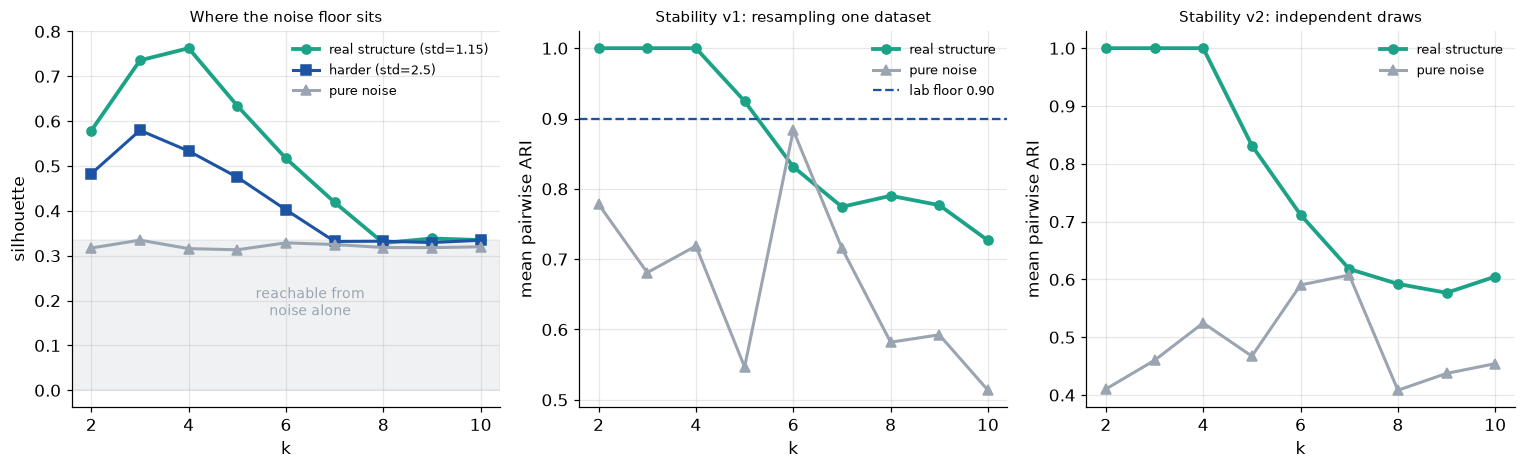

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

axes[0].plot(res_easy['k'], res_easy['silhouette'], 'o-', color=TEAL, linewidth=2.5,
             label='real structure (std=1.15)')
axes[0].plot(res_hard['k'], res_hard['silhouette'], 's-', color=BLUE, linewidth=2,
             label='harder (std=2.5)')
axes[0].plot(res_noise['k'], res_noise['silhouette'], '^-', color=GREY, linewidth=2,
             label='pure noise')
axes[0].axhspan(0, peak_noise, color=GREY, alpha=0.15)
axes[0].text(6.5, peak_noise / 2, 'reachable from\nnoise alone', color=GREY,
             fontsize=9, ha='center')
axes[0].set_xlabel('k'); axes[0].set_ylabel('silhouette')
axes[0].set_title('Where the noise floor sits', fontsize=10)
axes[0].legend(frameon=False, fontsize=8.5)

axes[1].plot(list(K_RANGE), stab_easy, 'o-', color=TEAL, linewidth=2.5, label='real structure')
axes[1].plot(list(K_RANGE), stab_noise, '^-', color=GREY, linewidth=2, label='pure noise')
axes[1].axhline(0.90, color=BLUE, linestyle='--', linewidth=1.5, label='lab floor 0.90')
axes[1].set_xlabel('k'); axes[1].set_ylabel('mean pairwise ARI')
axes[1].set_title('Stability v1: resampling one dataset', fontsize=10)
axes[1].legend(frameon=False, fontsize=8.5)

axes[2].plot(list(K_RANGE), cross_real, 'o-', color=TEAL, linewidth=2.5, label='real structure')
axes[2].plot(list(K_RANGE), cross_noise, '^-', color=GREY, linewidth=2, label='pure noise')
axes[2].set_xlabel('k'); axes[2].set_ylabel('mean pairwise ARI')
axes[2].set_title('Stability v2: independent draws', fontsize=10)
axes[2].legend(frameon=False, fontsize=8.5)

plt.tight_layout(); plt.show()

### Part 3 answers

**K-Means will still return clusters. What is the silhouette peak?**

**0.335, at k=3.** K-Means partitioned structureless data into three tidy, confident,
entirely meaningless groups - and nothing in its output indicates a problem.

**Where would you set the threshold for "this is probably not real"?**

The naive comparison is encouraging and misleading:

| | peak silhouette | peak margin |
|---|---|---|
| real structure (std=1.15) | 0.763 | 0.027 |
| pure noise | 0.335 | 0.006 |

2.28x on height. But 0.335 is *not* a low number by the standards of real published
clusterings - wine, in Part 5, has genuine structure and only reaches 0.285. **A fixed
height threshold would reject wine and accept nothing useful.** Two better signals:

**1. The margin, not the height.** The noise curve is flat: 0.313 to 0.335 across the whole
range k=2..10, and the "peak" beats its runner-up by 0.006. There is no peak there, only
sampling wobble in the third decimal. Real structure at std=1.15 has a peak that *means*
something even though its margin (0.027) is also modest.

**2. A calibrated floor, not a remembered one.** The floor is not a constant - it depends
on the shape of your data:

| dims (n=1200) | noise floor | | n (2-D) | noise floor |
|---|---|---|---|---|
| 2 | 0.335 | | 100 | 0.380 |
| 5 | 0.145 | | 300 | 0.351 |
| 10 | 0.073 | | 1200 | 0.335 |
| 20 | 0.039 | | 3000 | 0.339 |
| 50 | 0.018 | | | |

A 0.335 rule learned in 2-D is wrong in **both** directions. In 50-D it would reject a
silhouette of 0.15 that is more than 8x above that data's own noise floor - throwing away a
strong result. And small samples reach *higher* noise silhouettes (0.380 at n=100), so
small-n findings need a *higher* bar, not the same one.

So the answer is not a number, it is a procedure: **destroy the structure in your own data
and rerun the sweep.** Shuffling each column independently is the right null - it keeps
every feature's own distribution intact and removes only the relationships *between*
features, which is where cluster structure lives. Whatever silhouette that reaches is the
threshold for that dataset. Part 5 does exactly this on wine: 0.285 real against 0.075
shuffled, a ratio of 3.82x, which is convincing even though 0.285 is less than half the
synthetic 0.763.

**What does the stability test say?**

Two versions, because they answer different questions and only one of them is safe.

**Version 1 - resampling one dataset (the lab's `stability`):** real data 1.000 at k=2,3,4;
noise 0.514 to 0.883.

It separates them, but less cleanly than you would want: noise scored **0.883 at k=6,
higher than real structure at k=6 (0.831)**. The lab's 0.90 floor happens to hold on both,
but not by much. The reason is structural - every subsample of one noise dataset inherits
that dataset's accidental elongations, so the partitions genuinely agree with each other
about an artefact. **Reproducibility within one sample is not the same as reality.**

**Version 2 - independent draws from the same source** (centres held fixed; only the points
redrawn) is the stricter test, and it separates cleanly: real data **1.000** at k=2,3,4
decaying to 0.605; noise **never above 0.607**.

This is also the version where the bias the lab warns about is unmistakable: real data
scores a perfect **1.000 at k=2, k=3 *and* k=4** - a three-way tie. Splitting four
well-separated blobs into two groups is perfectly reproducible too, so a high stability
score cannot distinguish "correct" from "correct but coarser". **Stability filters; it
never selects.** Use it to eliminate, then let a metric with a real maximum choose from
the survivors - which is exactly what `choose_k` does in Part 5, and there it is the
diagnostic that carries the decision.

---
## Part 4: Find the elbow honestly

> Write a function that locates the elbow of the inertia curve automatically, by finding
> the point furthest from the straight line joining the first and last points of the curve.
>
> - Does it agree with the silhouette peak on our data?
> - Does it still agree on the harder data from Exercise 1?

One detail the brief does not mention but that decides whether the function works at all:
**the two axes have to be rescaled first.** `k` runs from 2 to 10; inertia runs into the
tens of thousands. In raw units the perpendicular distance to the chord is essentially the
vertical distance to it, so the "elbow" you find is partly an artefact of the units inertia
happens to be measured in. Mapping both axes to [0, 1] first makes the geometry mean what
the brief intends. Both versions are computed below, so the difference is visible rather
than asserted.

In [20]:
def elbow_k(k_values, curve, normalise=True):
    '''
    Locate the elbow of a monotone curve: the point lying furthest from the straight
    line joining its first and last points.

    normalise=True maps both axes to [0, 1] first, so the distance describes the SHAPE
    of the curve rather than the units its y-axis happens to use.

    Returns (chosen_k, distances) - distances are per-k, and their maximum doubles as a
    measure of how pronounced the bend is.
    '''
    x = np.asarray(k_values, dtype=float)
    y = np.asarray(curve, dtype=float)

    if normalise:
        x = (x - x.min()) / np.ptp(x)
        y = (y - y.min()) / np.ptp(y)

    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    unit = (p2 - p1) / np.linalg.norm(p2 - p1)

    offsets = np.column_stack([x, y]) - p1              # each point relative to p1
    along = offsets @ unit                              # component along the chord
    perpendicular = offsets - np.outer(along, unit)     # what is left is the distance
    distances = np.linalg.norm(perpendicular, axis=1)

    return int(np.asarray(k_values)[int(np.argmax(distances))]), distances


# Check it against the curve the lab annotated by hand.
k_elbow_easy, dist_easy = elbow_k(res_easy['k'], res_easy['inertia'])
k_elbow_easy_raw, dist_raw = elbow_k(res_easy['k'], res_easy['inertia'], normalise=False)

print('cluster_std = 1.15')
print(f'  elbow  (normalised axes) -> k = {k_elbow_easy}   (bend depth {dist_easy.max():.3f})')
print(f'  elbow  (raw axes)        -> k = {k_elbow_easy_raw}')
print(f'  silhouette peak          -> k = {best_easy}')
print(f'  truth                    -> k = {TRUE_K}')

cluster_std = 1.15
  elbow  (normalised axes) -> k = 4   (bend depth 0.504)
  elbow  (raw axes)        -> k = 4
  silhouette peak          -> k = 4
  truth                    -> k = 4


In [21]:
# The test that matters: does it still agree when the data gets harder, and does it
# know when there is nothing there at all?
datasets = [('std = 1.15 (baseline)', res_easy),
            ('std = 1.5', sweep_k(make_data(1.5)[0])),
            ('std = 2.5 (harder)', res_hard),
            ('std = 4.0', sweep_k(make_data(4.0)[0])),
            ('std = 6.0', sweep_k(make_data(6.0)[0])),
            ('pure noise', res_noise)]

print(f'{"dataset":>22}  {"elbow":>6}  {"bend depth":>11}  {"silhouette":>11}  '
      f'{"sil peak":>9}  {"agree?":>7}')
elbow_rows = []
for name, res in datasets:
    k_e, dists = elbow_k(res['k'], res['inertia'])
    k_s = res['k'][int(np.argmax(res['silhouette']))]
    elbow_rows.append((name, k_e, dists.max(), k_s))
    print(f'{name:>22}  {k_e:>6}  {dists.max():>11.3f}  {k_s:>11}  '
          f'{max(res["silhouette"]):>9.3f}  {"yes" if k_e == k_s else "NO":>7}')

print('\nThe elbow k barely moves. The BEND DEPTH is the column that carries information:')
depths = {n: d for n, _, d, _ in elbow_rows}
print(f'  real structure (std=1.15): {depths["std = 1.15 (baseline)"]:.3f}')
print(f'  pure noise:                {depths["pure noise"]:.3f}')
print(f'  ratio: {depths["std = 1.15 (baseline)"] / depths["pure noise"]:.2f}x')

               dataset   elbow   bend depth   silhouette   sil peak   agree?
 std = 1.15 (baseline)       4        0.504            4      0.763      yes
             std = 1.5       4        0.486            3      0.695       NO
    std = 2.5 (harder)       4        0.426            3      0.579       NO
             std = 4.0       4        0.344            3      0.454       NO
             std = 6.0       4        0.290            3      0.375       NO
            pure noise       4        0.256            3      0.335       NO

The elbow k barely moves. The BEND DEPTH is the column that carries information:
  real structure (std=1.15): 0.504
  pure noise:                0.256
  ratio: 1.97x


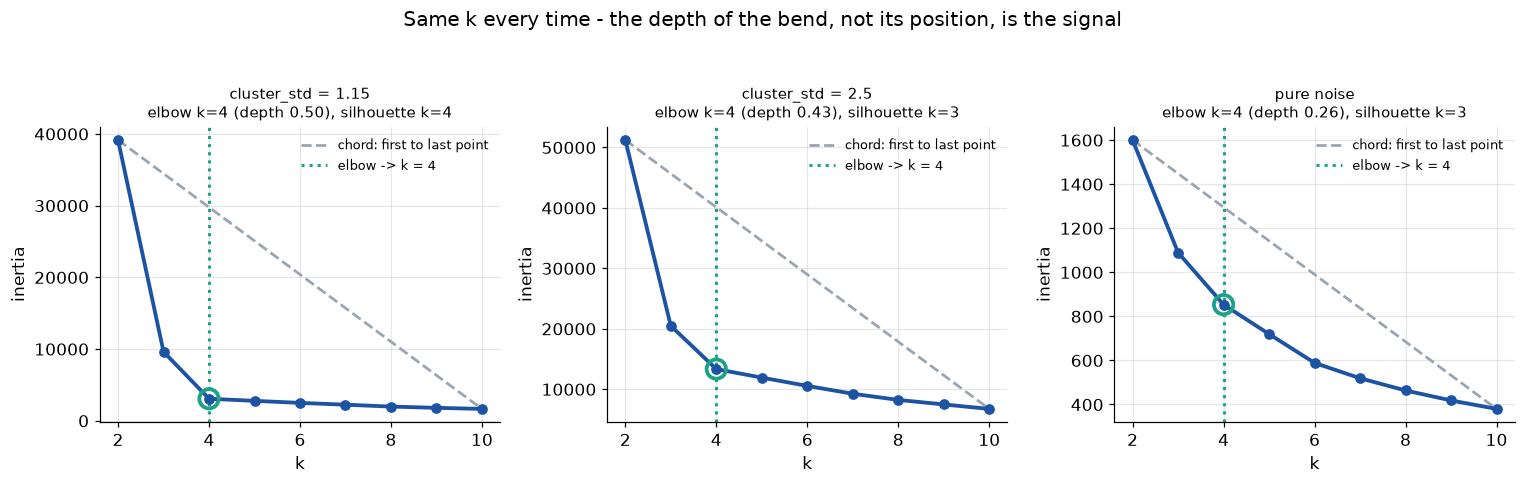

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, (name, res) in zip(axes, [('cluster_std = 1.15', res_easy),
                                  ('cluster_std = 2.5', res_hard),
                                  ('pure noise', res_noise)]):
    ks, inertia = res['k'], res['inertia']
    k_e, dists = elbow_k(ks, inertia)
    k_s = ks[int(np.argmax(res['silhouette']))]

    ax.plot(ks, inertia, 'o-', color=BLUE, linewidth=2.5, zorder=3)
    ax.plot([ks[0], ks[-1]], [inertia[0], inertia[-1]], '--', color=GREY,
            linewidth=1.8, label='chord: first to last point')
    ax.axvline(k_e, color=TEAL, linewidth=2, linestyle=':', label=f'elbow -> k = {k_e}')
    ax.scatter([k_e], [inertia[ks.index(k_e)]], s=160, facecolor='none',
               edgecolor=TEAL, linewidth=2.5, zorder=4)
    ax.set_title(f'{name}\nelbow k={k_e} (depth {dists.max():.2f}), silhouette k={k_s}',
                 fontsize=10)
    ax.set_xlabel('k'); ax.set_ylabel('inertia')
    ax.legend(frameon=False, fontsize=8.5)

plt.suptitle('Same k every time - the depth of the bend, not its position, is the signal',
             y=1.04)
plt.tight_layout(); plt.show()

### Part 4 answers

**Does it agree with the silhouette peak on our data?** Yes. On `cluster_std=1.15` the
elbow finder returns **k = 4**, matching both the silhouette peak and the truth. The
normalised and raw-axis versions agree here too, though normalising remains the right
default - in raw units the perpendicular distance is dominated by inertia's scale, so the
answer partly reflects the units rather than the shape.

**Does it still agree on the harder data?** No - and the reason is worse than mere
disagreement:

| dataset | elbow | bend depth | silhouette peak |
|---|---|---|---|
| std = 1.15 | 4 | 0.504 | 4 |
| std = 1.5 | 4 | 0.486 | 3 |
| std = 2.5 | 4 | 0.426 | 3 |
| std = 4.0 | 4 | 0.344 | 3 |
| std = 6.0 | 4 | 0.290 | 3 |
| **pure noise** | **4** | 0.256 | 3 |

**The elbow returns k = 4 on every single dataset - including pure noise with no structure
whatsoever.** It agreed with the truth once, at std=1.15, by coincidence; on wine in Part 5
it says 4 when the answer is 3. A function that answers "4" regardless of the question is
not measuring the question.

Why: inertia falls smoothly and convexly whether or not clusters exist. The chord-distance
construction is a **curvature detector**, and the position of maximum curvature on a smooth
convex decay is set by the shape of that decay and by the k-range you happened to sweep -
not by how many groups are in the data. This is the lab's own thesis reasserting itself one
level up. Inertia always falls, so it cannot choose k; **automating the reading of the
elbow does not repair that, it just hides it behind a function call.**

What *does* carry information is the **depth** of the bend - the maximum perpendicular
distance itself, which the notebook returns alongside the choice. It falls monotonically
as the structure dissolves (0.504, 0.486, 0.426, 0.344, 0.290) and reaches 0.256 on noise:
**1.97x between real structure and none.** That is a usable *strength* signal, on the same
footing as the silhouette height in Part 3 - and with the same requirement, that it be
compared against a shuffled null for your own dataset rather than against a memorised
constant. Note it is a weaker separator than silhouette's 2.28x, and its dynamic range is
narrow.

**Practical conclusion:** the elbow is a free sanity check to run alongside a real selector,
and a reasonable tie-breaker when silhouette and Davies-Bouldin disagree. It never gets a
vote of its own. If it is your only diagnostic, you have no diagnostic - you have a
function that says 4.

---
## Part 5: Take it to real data

> Load a dataset with no obvious answer key, run `choose_k` on it. The true number of
> classes is 3, but **do not look** until you have committed to an answer from the metrics
> alone. Then compare - and if you were wrong, work out which diagnostic would have warned
> you.

`choose_k` is the lab's checklist function, copied unchanged. The discipline it encodes:
stability is biased towards small k, so it can only *filter*; silhouette and Davies-Bouldin
have real optima, so they *select* - but only from among the survivors.

In [23]:
STABILITY_FLOOR = 0.90   # below this, a partition is not reproducible enough to report


def choose_k(X, k_range=K_RANGE, seed=SEED, verbose=True):
    '''
    Lab Part 6.3, unchanged.

      silhouette      - has a real maximum, so it can SELECT k
      Davies-Bouldin  - has a real minimum, so it can SELECT k (second opinion)
      stability       - biased towards small k, so it can only FILTER k
    '''
    results = {}
    for k in k_range:
        labels = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X)
        results[k] = {
            'silhouette': silhouette_score(X, labels),
            'davies_bouldin': davies_bouldin_score(X, labels),
            'stability': stability(X, k, n_trials=8, seed=seed),
        }

    stable = [k for k in results if results[k]['stability'] >= STABILITY_FLOOR]
    if not stable:
        stable = list(results)

    by_silhouette = max(stable, key=lambda k: results[k]['silhouette'])
    by_davies = min(stable, key=lambda k: results[k]['davies_bouldin'])

    if verbose:
        print(f'{"k":>3}  {"silhouette":>11}  {"Davies-Bouldin":>15}  {"stability":>10}  {"":>8}')
        for k, r in results.items():
            mark = 'stable' if r['stability'] >= STABILITY_FLOOR else ''
            print(f'{k:>3}  {r["silhouette"]:>11.3f}  {r["davies_bouldin"]:>15.3f}'
                  f'  {r["stability"]:>10.3f}  {mark:>8}')

        print(f'\n  FILTER    stability >= {STABILITY_FLOOR} keeps k in {stable}')
        print(f'  SELECT    silhouette peak within that range  -> k = {by_silhouette}')
        print(f'  SELECT    Davies-Bouldin minimum within it   -> k = {by_davies}')

        if by_silhouette == by_davies:
            print(f'\n  -> Both selectors agree on k = {by_silhouette}, and it is stable.')
        else:
            print(f'\n  -> Selectors disagree ({by_silhouette} vs {by_davies}).')
            print('     Report the range rather than a single number.')

    return results


wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)
print(f'wine: {X_wine.shape[0]} samples, {X_wine.shape[1]} standardised features')
print('(the label vector exists but stays sealed until two cells from now)')

wine: 178 samples, 13 standardised features
(the label vector exists but stays sealed until two cells from now)


In [24]:
# Committing to an answer from the metrics alone.
res_wine = choose_k(X_wine)

inertia_wine = [KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_wine).inertia_
                for k in K_RANGE]
k_elbow_wine, dist_wine = elbow_k(list(K_RANGE), inertia_wine)
print(f'\n  elbow of the inertia curve  -> k = {k_elbow_wine}  '
      f'(bend depth {dist_wine.max():.3f})')

# The Part 3 discipline: is this score even distinguishable from no structure?
# Shuffle each column independently. That destroys the relationships BETWEEN features
# while keeping every feature's own distribution intact - the right null model.
rng = np.random.default_rng(SEED)
X_null = np.column_stack([rng.permutation(col) for col in X_wine.T])
sil_null = [silhouette_score(X_null, KMeans(n_clusters=k, n_init=10, random_state=SEED)
                             .fit_predict(X_null)) for k in K_RANGE]
sil_wine = [res_wine[k]['silhouette'] for k in K_RANGE]
print(f'\n  wine peak silhouette                     : {max(sil_wine):.3f}')
print(f'  same data, columns shuffled (null model) : {max(sil_null):.3f}')
print(f'  ratio: {max(sil_wine) / max(sil_null):.2f}x  -> the structure clears its own null')

  k   silhouette   Davies-Bouldin   stability          
  2        0.259            1.526       0.719          
  3        0.285            1.389       0.975    stable
  4        0.260            1.797       0.809          
  5        0.202            1.808       0.773          
  6        0.237            1.554       0.649          
  7        0.204            1.661       0.659          
  8        0.157            1.741       0.545          
  9        0.150            1.708       0.548          
 10        0.144            1.707       0.529          

  FILTER    stability >= 0.9 keeps k in [3]
  SELECT    silhouette peak within that range  -> k = 3
  SELECT    Davies-Bouldin minimum within it   -> k = 3

  -> Both selectors agree on k = 3, and it is stable.



  elbow of the inertia curve  -> k = 4  (bend depth 0.244)



  wine peak silhouette                     : 0.285
  same data, columns shuffled (null model) : 0.075
  ratio: 3.82x  -> the structure clears its own null


In [25]:
# Now open the envelope.
y_wine = wine.target
print(f'true number of classes: {len(np.unique(y_wine))}   sizes: {np.bincount(y_wine)}')

ari_wine = []
print(f'\n{"k":>3}  {"silhouette":>11}  {"stability":>10}  {"ARI vs truth":>13}')
for k in K_RANGE:
    labels = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_wine)
    ari = adjusted_rand_score(y_wine, labels)
    ari_wine.append(ari)
    mark = '  <-- true k' if k == 3 else ''
    print(f'{k:>3}  {res_wine[k]["silhouette"]:>11.3f}  {res_wine[k]["stability"]:>10.3f}'
          f'  {ari:>13.3f}{mark}')

print(f'\nsilhouette peaks at k = {list(K_RANGE)[int(np.argmax(sil_wine))]}')
print(f'stability peaks at  k = '
      f'{list(K_RANGE)[int(np.argmax([res_wine[k]["stability"] for k in K_RANGE]))]}')
print(f'ARI peaks at        k = {list(K_RANGE)[int(np.argmax(ari_wine))]}')
print(f'elbow said          k = {k_elbow_wine}')

true number of classes: 3   sizes: [59 71 48]



  k   silhouette   stability   ARI vs truth


  2        0.259       0.719          0.374


  3        0.285       0.975          0.897  <-- true k


  4        0.260       0.809          0.765


...

  6        0.237       0.649          0.639


  7        0.204       0.659          0.566


  8        0.157       0.545          0.415


  9        0.150       0.548          0.385


 10        0.144       0.529          0.344

silhouette peaks at k = 3
stability peaks at  k = 3
ARI peaks at        k = 3
elbow said          k = 4


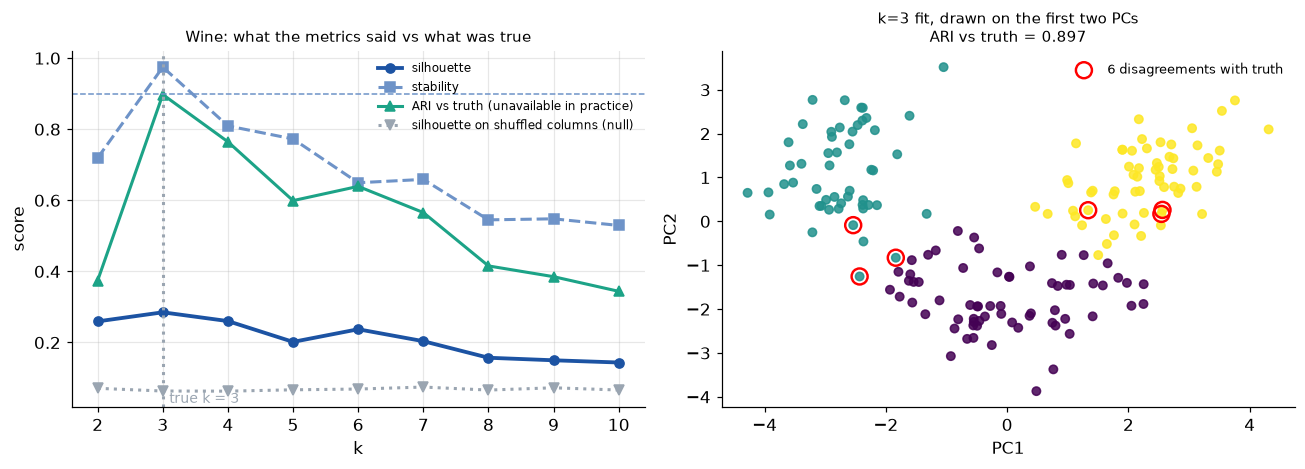

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].plot(list(K_RANGE), sil_wine, 'o-', color=BLUE, linewidth=2.5, label='silhouette')
axes[0].plot(list(K_RANGE), [res_wine[k]['stability'] for k in K_RANGE], 's--',
             color=PALE, linewidth=2, label='stability')
axes[0].plot(list(K_RANGE), ari_wine, '^-', color=TEAL, linewidth=2,
             label='ARI vs truth (unavailable in practice)')
axes[0].plot(list(K_RANGE), sil_null, 'v:', color=GREY, linewidth=2,
             label='silhouette on shuffled columns (null)')
axes[0].axvline(3, color=GREY, linestyle=':', linewidth=2)
axes[0].axhline(STABILITY_FLOOR, color=PALE, linestyle='--', linewidth=1)
axes[0].text(3.1, 0.03, 'true k = 3', color=GREY, fontsize=9)
axes[0].set_xlabel('k'); axes[0].set_ylabel('score')
axes[0].set_title('Wine: what the metrics said vs what was true', fontsize=10)
axes[0].legend(frameon=False, fontsize=8)

# 13-D data projected to 2-D just so the result is lookable-at.
XY = PCA(n_components=2, random_state=SEED).fit_transform(X_wine)
labels3 = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit_predict(X_wine)
axes[1].scatter(XY[:, 0], XY[:, 1], c=labels3, cmap='viridis', s=30, alpha=0.85)

# Mark the points the clustering put in a different group from their true class.
# (Matched by majority vote, since cluster ids are arbitrary names - lab Part 1.)
match = {}
for c in range(3):
    match[c] = int(np.bincount(y_wine[labels3 == c], minlength=3).argmax())
mismatch = np.array([match[c] for c in labels3]) != y_wine
axes[1].scatter(XY[mismatch, 0], XY[mismatch, 1], facecolor='none', edgecolor='red',
                s=110, linewidth=1.6, label=f'{mismatch.sum()} disagreements with truth')
axes[1].set_title(f'k=3 fit, drawn on the first two PCs\n'
                  f'ARI vs truth = {adjusted_rand_score(y_wine, labels3):.3f}', fontsize=10)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(frameon=False, fontsize=8.5)
axes[1].grid(False)

plt.tight_layout(); plt.show()

### Part 5 answers

**Committed answer, from the metrics alone: k = 3.**

The stability filter was decisive on its own - only k=3 cleared 0.90 (**0.975**, next best
k=4 at 0.809), which reduced the field to a single candidate before either selector spoke.
Both then agreed independently: silhouette peaked at 3 (0.285) and Davies-Bouldin bottomed
at 3 (1.389).

Pre-registered null check, applying Part 3's lesson before looking at any label:
**0.285 against 0.075** on column-shuffled data, a ratio of **3.82x**. So the structure
clears its own null convincingly, even though 0.285 would look feeble measured against the
synthetic blobs' 0.763.

**Then the envelope: 3 classes, sizes [59, 71, 48]. Correct.**

| k | silhouette | stability | ARI vs truth |
|---|---|---|---|
| 2 | 0.259 | 0.719 | 0.374 |
| **3** | **0.285** | **0.975** | **0.897** |
| 4 | 0.260 | 0.809 | 0.765 |

All three internal diagnostics and the external ARI peak at the same k, and the k=3 fit
scores **ARI 0.897** - 6 points misassigned out of 178, visible as the red rings in the
PCA plot.

**Which diagnostic would have warned me?** None needed to, but the question is still worth
answering, because two things could easily have gone wrong here:

- **The elbow said k = 4** (bend depth 0.244). Used as the selector it would have committed
  me to 4 and been wrong - ARI 0.765 instead of 0.897. Exactly as Part 4 predicted: the
  elbow says 4 almost regardless of the data.
- **Stability was the load-bearing diagnostic, and silhouette nearly failed.** The
  silhouette gap between k=3 (0.285) and k=4 (0.260) is **0.025** - by Part 1's standard a
  thin margin, in the range where I argued you should refuse to commit. On silhouette alone
  this was close to a coin toss. Stability broke the tie decisively at 0.975 vs 0.809.

That last point looks like it contradicts the lab's Part 6.3 warning (stability is biased
towards small k, so filter with it, never select), and it does not - which is worth being
precise about. Stability earned its keep here through its **low** values, eliminating k=2
(0.719) and everything from k=4 up. It was never asked to point at a maximum. And note it
did not simply prefer the smallest k available: **k=2 failed the filter**, because a 2-way
split of three overlapping classes is not reproducible either. The bias is real but it is
not unconditional.

One more thing worth carrying away. Wine's peak silhouette is 0.285 - **less than half** the
synthetic data's 0.763 - and yet the answer is right, with ARI 0.897. Real classes overlap;
that is what real data looks like. **Absolute silhouette values are not comparable across
datasets.** Only comparisons *within* a dataset mean anything: across k, and against that
dataset's own shuffled null.

---
## Summary

| Part | Question | Answer |
|---|---|---|
| 1 | Does silhouette still peak at 4 at std=2.5? | No - k=3, with k=4 second |
| 1 | Where does it break? | Between std **1.4 and 1.5**, but the margin collapses to 0.006 at 1.4 while the answer is still right |
| 1 | What does a flat peak mean? | Not enough evidence to prefer one k - report a range. And a *large* margin means nothing: it grows back to 0.058 while pointing at the wrong k |
| 1 | Why k=3 and not some other error? | Centres 0 and 3 are 6.55 apart vs >=10.03 for every other pair; the closest pair merges first |
| 2 | What does K-Means do to the wide cluster? | Nothing at all in the brief's setting (ARI 0.987). Once it genuinely overlaps: quarters it across all four clusters (ARI 0.323) and inflates the tight clusters to 60-64% purity |
| 2 | Why? | It minimises squared distance over a Voronoi tessellation, so it prefers cells of equal radius - it fitted 1.5-2.7 to true radii of 0.5-4.3 |
| 2 | Does DBSCAN handle it better? | Yes, 0.907 vs 0.323 - but by calling 49.5% of the data noise, and it collapses to one cluster (ARI ~ 0) once eps bridges the wide cluster |
| 3 | Silhouette peak on pure noise? | **0.335 at k=3**, margin 0.006, curve flat from 0.313 to 0.335 |
| 3 | Where is the threshold? | Not a number. The floor runs 0.335 (2-D) to 0.018 (50-D), and is *higher* for small n. Shuffle your own columns and use what you get |
| 3 | What does stability say? | Subsampling one dataset is partly fooled (noise 0.883 at k=6 > real 0.831). Independent draws separate cleanly: real 1.000, noise never above 0.607 |
| 3 | Can stability choose k? | No - it ties at 1.000 for k=2, 3 and 4 on real data. It filters only |
| 4 | Does the elbow agree with silhouette? | Only on the easy data. It returns **k=4 on all six datasets, including pure noise** |
| 4 | Is it usable at all? | Its position, no. Its **bend depth**, yes: 0.504 real vs 0.256 noise, falling monotonically as structure dissolves |
| 5 | `choose_k` on wine? | **k=3 - correct.** ARI 0.897, and 0.285 vs 0.075 against its own shuffled null |
| 5 | Which diagnostic mattered? | **Stability** (0.975 vs 0.809). Silhouette's margin was only 0.025. The elbow said 4 and would have been wrong |

### What this adds to the lab

The lab's closing sentence was: *a metric that improves every time you add complexity cannot
be used to choose complexity.* Inertia and reconstruction error fail that test; silhouette,
held-out likelihood, BIC and stability pass it.

What these five exercises add is that **passing that test is necessary but not sufficient.**
Every surviving metric still fails quietly, and each has a specific tell:

- **Silhouette** - the *margin*, not the height, tells you whether the peak is a decision.
  It went flat (0.006) one step before it went wrong, and its confidence came *back* while
  pointing at the wrong answer.
- **Every threshold is dataset-specific.** The noise floor moved 18-fold across
  dimensionality alone. Calibrate against a shuffled null; never carry a remembered number
  between datasets.
- **Stability filters, it never selects** - it tied across k=2, 3 and 4 on clean data. And
  resampling one dataset is a strictly weaker test than redrawing from the source, because
  every subsample inherits the same accidents.
- **The elbow is a curvature detector, not a cluster detector.** It answered "4" to every
  question asked of it, noise included.
- **Selection breaks long before clustering does.** Across std 1.5 to 4.0, K-Means at k=4
  recovers the truth well (ARI 0.98 down to 0.59) while no internal metric will tell you
  that 4 was the right thing to ask for. The two failures are separate and worth reporting
  separately.
- **The algorithm's assumptions decide the failure mode.** K-Means cannot represent unequal
  radii and responds by moving boundaries and silently contaminating good clusters; DBSCAN
  can, and responds by calling half the data noise or welding everything into one. Neither
  is a bug - both are the model class showing through.

The practical habit all six point at: **never report one number from one metric on one
sample.** Report the range the metrics allow, the null you compared against, and the
diagnostic that actually decided it.